# Dataset

In [1]:
import numpy as np
import torch

# ============================================================
# 2D OU Dataset with random t
# x0 ~ N((10,10), 2I)
# dX_t = - beta X_t dt + sigma dW_t
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dim = 2

mu0_np = np.array([10.0, 10.0], dtype=np.float32)
var0 = 2.0
std0 = np.sqrt(var0)

beta = 1.0
sigma = np.sqrt(beta * 2.0)

T = 5.0
eps_t = 1e-3

N = 10000

# x0 ~ N(mu0, var0 I)
x0_np = (
    np.random.randn(N, dim).astype(np.float32) * std0
    + mu0_np
)

# random t ~ Uniform(eps_t, T)
t_np = np.random.uniform(
    eps_t,
    T,
    N
).astype(np.float32)

# reshape for broadcasting
t_col = t_np.reshape(-1, 1)

# OU conditional mean and variance
a_t_np = np.exp(-beta * t_col).astype(np.float32)

cond_var_t_np = (
    sigma**2 / (2 * beta)
    * (1 - np.exp(-2 * beta * t_col))
).astype(np.float32)

cond_std_t_np = np.sqrt(cond_var_t_np).astype(np.float32)

# xt | x0
eps_np = np.random.randn(N, dim).astype(np.float32)

xt_np = (
    a_t_np * x0_np
    + cond_std_t_np * eps_np
).astype(np.float32)

# OU marginal mean and variance
mu_t_np = (
    a_t_np * mu0_np
).astype(np.float32)

var_t_np = (
    (a_t_np**2) * var0
    + cond_var_t_np
).astype(np.float32)

# exact marginal score ∇ log p_t(x)
score_t_np = (
    -(xt_np - mu_t_np)
    / var_t_np
).astype(np.float32)

# conditional score ∇ log p(xt | x0)
cond_score_np = (
    -(xt_np - a_t_np * x0_np)
    / cond_var_t_np
).astype(np.float32)

# torch tensors
mu0 = torch.tensor(mu0_np, device=device)

x0_train = torch.tensor(x0_np, device=device)
xt_train = torch.tensor(xt_np, device=device)
t_train = torch.tensor(t_np, device=device).view(-1, 1)

score_t_train = torch.tensor(score_t_np, device=device)
cond_score_train = torch.tensor(cond_score_np, device=device)

print("t range:", t_np.min(), t_np.max())
print("xt empirical mean:", xt_np.mean(axis=0))
print("xt empirical var:", xt_np.var(axis=0))
print("score empirical mean:", score_t_np.mean(axis=0))
print("cond_score empirical mean:", cond_score_np.mean(axis=0))

print("x0_train shape:", x0_train.shape)
print("xt_train shape:", xt_train.shape)
print("t_train shape:", t_train.shape)
print("score_t_train shape:", score_t_train.shape)
print("cond_score_train shape:", cond_score_train.shape)

t range: 0.003039064 4.9997873
xt empirical mean: [1.9791553 1.9853531]
xt empirical var: [7.088194 7.211915]
score empirical mean: [0.00247792 0.0004    ]
cond_score empirical mean: [ 0.01077685 -0.00506343]
x0_train shape: torch.Size([10000, 2])
xt_train shape: torch.Size([10000, 2])
t_train shape: torch.Size([10000, 1])
score_t_train shape: torch.Size([10000, 2])
cond_score_train shape: torch.Size([10000, 2])


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

class ScoreNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(3, 64),   # x1, x2, t
            nn.SiLU(),

            nn.Linear(64, 64),
            nn.SiLU(),

            nn.Linear(64, 2)    # score_x1, score_x2
        )

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1)
        return self.net(inp)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ScoreNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

x0_train = x0_train.to(device)
xt_train = xt_train.to(device)
t_train = t_train.to(device)
score_t_train = score_t_train.to(device)
cond_score_train = cond_score_train.to(device)

# Training

In [3]:
import copy

# ============================================================
# 2D Time-dependent OU training
# save models at different epochs
# ============================================================

T = 5.0
eps_t = 0.05

epochs = 300
batch_size = 2048

save_epochs = [10, 20, 50, 100, 150, 200, 250, 300]
saved_models = {}

L_ESM_history = []
L_ISM_history = []
L_DSM_history = []
I_DSM_history = []

for epoch in range(1, epochs + 1):

    # sample x0 ~ N((10,10), 2I)
    x0 = (
        torch.randn(batch_size, dim, device=device)
        * np.sqrt(var0)
        + mu0
    )

    # sample t ~ Uniform(eps_t, T)
    t_batch = (
        eps_t
        + (T - eps_t) * torch.rand(batch_size, 1, device=device)
    )

    # OU coefficients
    a_t = torch.exp(-beta * t_batch)

    cond_var_t = (
        sigma**2 / (2 * beta)
        * (1 - torch.exp(-2 * beta * t_batch))
    )

    cond_std_t = torch.sqrt(cond_var_t)

    # generate xt
    eps = torch.randn_like(x0)

    xt = (
        a_t * x0
        + cond_std_t * eps
    )

    xt.requires_grad_(True)

    # marginal distribution p_t(x)
    mu_t = a_t * mu0

    var_t = (
        (a_t**2) * var0
        + cond_var_t
    )

    # exact marginal score
    score_t = (
        -(xt - mu_t)
        / var_t
    )

    # conditional score
    cond_score = (
        -(xt - a_t * x0)
        / cond_var_t
    )

    # network prediction
    pred_score = model(xt, t_batch)

    # L_ESM
    L_ESM = (
        (pred_score - score_t) ** 2
    ).sum(dim=1).mean()

    # L_ISM
    div_score = 0

    for j in range(dim):

        grad_j = torch.autograd.grad(
            outputs=pred_score[:, j].sum(),
            inputs=xt,
            create_graph=True,
            retain_graph=True
        )[0][:, j]

        div_score = div_score + grad_j

    L_ISM = (
        (pred_score ** 2).sum(dim=1)
        + 2 * div_score
    ).mean()

    # L_DSM
    L_DSM = (
        (pred_score - cond_score) ** 2
    ).sum(dim=1).mean()

    # I_DSM
    I_DSM = (
        (pred_score ** 2).sum(dim=1)
        - (pred_score * cond_score).sum(dim=1)
    ).mean()

    # train
    loss = L_ESM

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # record
    L_ESM_history.append(L_ESM.item())
    L_ISM_history.append(L_ISM.item())
    L_DSM_history.append(L_DSM.item())
    I_DSM_history.append(I_DSM.item())

    # save model checkpoint
    if epoch in save_epochs:
        saved_models[epoch] = copy.deepcopy(model.state_dict())

    # print
    if epoch in save_epochs:
        print(
            f"Epoch {epoch:4d} | "
            f"L_ESM = {L_ESM.item():.8f} | "
            f"L_ISM = {L_ISM.item():.8f} | "
            f"L_DSM = {L_DSM.item():.8f} | "
            f"I_DSM = {I_DSM.item():.8f}"
        )

Epoch   10 | L_ESM = 1.53291988 | L_ISM = -0.35706845 | L_DSM = 2.15703845 | I_DSM = -0.13950677
Epoch   20 | L_ESM = 1.07829952 | L_ISM = -0.80189550 | L_DSM = 1.64362013 | I_DSM = -0.30334824
Epoch   50 | L_ESM = 0.43715850 | L_ISM = -1.46808398 | L_DSM = 0.94399929 | I_DSM = -0.09590240
Epoch  100 | L_ESM = 0.19240788 | L_ISM = -1.67052865 | L_DSM = 0.79660356 | I_DSM = -0.02550893
Epoch  150 | L_ESM = 0.12803981 | L_ISM = -1.70773768 | L_DSM = 0.74566543 | I_DSM = -0.04567577
Epoch  200 | L_ESM = 0.08789032 | L_ISM = -1.81137574 | L_DSM = 0.63315731 | I_DSM = -0.02623274
Epoch  250 | L_ESM = 0.05846134 | L_ISM = -1.77604890 | L_DSM = 0.56378859 | I_DSM = -0.02721222
Epoch  300 | L_ESM = 0.03383662 | L_ISM = -1.84933889 | L_DSM = 0.68201673 | I_DSM = -0.01644998


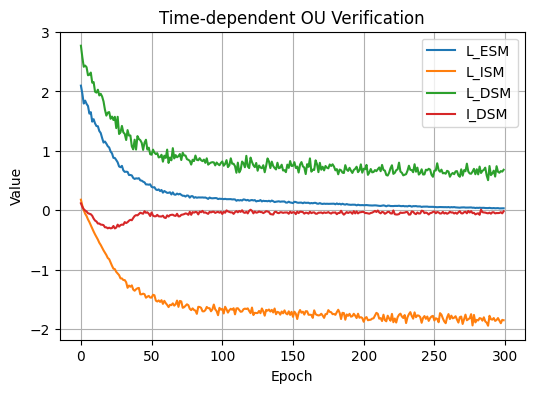

In [4]:
plt.figure(figsize=(6,4))

plt.plot(L_ESM_history, label='L_ESM')
plt.plot(L_ISM_history, label='L_ISM')
plt.plot(L_DSM_history, label='L_DSM')
plt.plot(I_DSM_history, label='I_DSM')

plt.xlabel("Epoch")
plt.ylabel("Value")

plt.title("Time-dependent OU Verification")

plt.legend()
plt.grid(True)

plt.show()

# Reverse


In [11]:
results = []

steps = 1000
dt = T / steps

epoch_list = [10,20,50,100,150,200,250,300]

num_samples = 10000

for epoch in epoch_list:

    model.load_state_dict(saved_models[epoch])
    model.eval()

    # ========================================================
    # p_T
    # ========================================================

    a_T = np.exp(-beta * T)

    cond_var_T = (
        sigma**2/(2*beta)
        * (1 - np.exp(-2*beta*T))
    )

    mu_T = a_T * mu0

    var_T = (
        (a_T**2)*var0
        + cond_var_T
    )

    x = (
        torch.randn(num_samples, dim, device=device)
        * np.sqrt(var_T)
        + mu_T
    )

    # ========================================================
    # reverse sampling
    # ========================================================

    with torch.no_grad():

        for i in range(steps):

            t_now = T - i*dt
            t_now = max(t_now,1e-5)

            t_tensor = (
                torch.ones(num_samples,1,device=device)
                * t_now
            )

            score = model(x,t_tensor)

            noise = torch.randn_like(x)

            x = (
                x
                + (beta*x + sigma**2*score)*dt
                + sigma*np.sqrt(dt)*noise
            )

    samples_reverse = x.cpu().numpy()

    reverse_mean = samples_reverse.mean(axis=0)
    reverse_std = samples_reverse.std(axis=0)

    results.append({

        "epoch": epoch,

        "mean_x1": reverse_mean[0],
        "mean_x2": reverse_mean[1],

        "std_x1": reverse_std[0],
        "std_x2": reverse_std[1],

        "mean_error_norm":
            np.linalg.norm(
                reverse_mean
                - mu0.cpu().numpy()
            ),

        "std_error_norm":
            np.linalg.norm(
                reverse_std
                - np.sqrt(var0)
            )
    })

import pandas as pd
df_results = pd.DataFrame(results)
display(df_results)

,epoch,mean_x1,mean_x2,std_x1,std_x2,mean_error_norm,std_error_norm
0,10,-47.067192,-19.207077,147.677277,106.453690,64.107079,180.072694
1,20,-27.705988,-6.062537,123.450668,82.010345,40.984711,146.248531
2,50,5.197265,5.528372,30.802179,31.070566,6.562143,41.751069
3,100,10.150496,10.112838,6.152921,6.172431,0.188100,6.715354
4,150,9.667280,9.664186,4.894486,5.040616,0.472730,5.026240
5,200,8.329839,8.219198,68.122749,71.759560,2.441453,96.945843
6,250,9.317700,9.315270,24.707071,25.859715,0.966637,33.765955
7,300,9.667034,9.675384,6.640801,6.806636,0.465018,7.509690


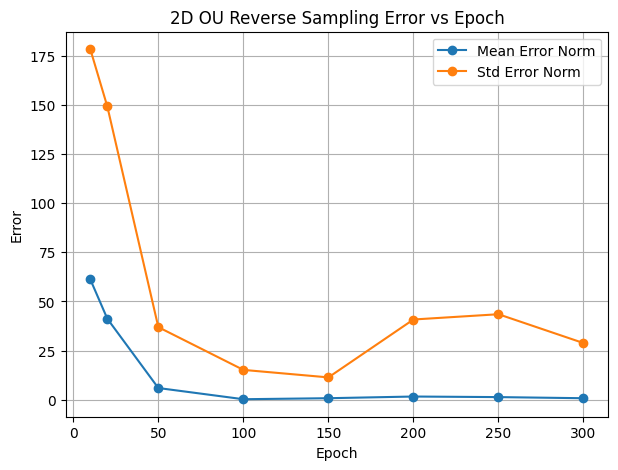

In [7]:
plt.figure(figsize=(7,5))

plt.plot(
    df_results["epoch"],
    df_results["mean_error_norm"],
    marker="o",
    label="Mean Error Norm"
)

plt.plot(
    df_results["epoch"],
    df_results["std_error_norm"],
    marker="o",
    label="Std Error Norm"
)

plt.xlabel("Epoch")
plt.ylabel("Error")
plt.title("2D OU Reverse Sampling Error vs Epoch")

plt.grid(True)
plt.legend()

plt.show()

# Reverse 2

In [8]:
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

T = 5.0
beta = 1.0
var0 = 2.0
sigma = np.sqrt(2.0)

dim = 2
mu0 = torch.tensor([10.0, 10.0], device=device)

num_samples = 10000
num_eval = 10000
steps = 1000
dt = T / steps

epoch_list = [10, 20, 50, 100, 150, 200, 250, 300]

def ou_params(t):
    a_t = np.exp(-beta * t)
    cond_var_t = sigma**2 / (2 * beta) * (1 - np.exp(-2 * beta * t))
    mu_t = a_t * mu0
    var_t = (a_t**2) * var0 + cond_var_t
    return a_t, cond_var_t, mu_t, var_t

def compute_losses(model, x_eval, t_now):
    x_eval = x_eval.clone().detach().requires_grad_(True)
    t_tensor = torch.ones(x_eval.shape[0], 1, device=device) * t_now

    pred_score = model(x_eval, t_tensor)

    a_t, cond_var_t, mu_t, var_t = ou_params(t_now)

    marginal_score = -(x_eval - mu_t) / var_t

    post_mean = mu0 + (a_t * var0 / var_t) * (x_eval - mu_t)

    post_var = var0 - (a_t**2 * var0**2) / var_t

    x0_post = (
        post_mean
        + torch.sqrt(torch.tensor(post_var, device=device, dtype=x_eval.dtype))
        * torch.randn_like(post_mean)
    )

    cond_score = -(x_eval - a_t * x0_post) / cond_var_t

    L_ESM = ((pred_score - marginal_score) ** 2).sum(dim=1).mean()
    L_DSM = ((pred_score - cond_score) ** 2).sum(dim=1).mean()

    div_score = 0
    for j in range(dim):
        grad_j = torch.autograd.grad(
            outputs=pred_score[:, j].sum(),
            inputs=x_eval,
            create_graph=False,
            retain_graph=True
        )[0][:, j]
        div_score = div_score + grad_j

    L_ISM = ((pred_score ** 2).sum(dim=1) + 2 * div_score).mean()

    I_DSM = (
        (pred_score ** 2).sum(dim=1)
        - (pred_score * cond_score).sum(dim=1)
    ).mean()

    return {
        "L_ESM": L_ESM.item(),
        "L_DSM": L_DSM.item(),
        "L_ISM": L_ISM.item(),
        "I_DSM": I_DSM.item(),
    }

t_eval_for_loss = 1.0
a_eval, cond_var_eval, mu_eval, var_eval = ou_params(t_eval_for_loss)

x_eval_for_loss = (
    torch.randn(num_eval, dim, device=device)
    * np.sqrt(var_eval)
    + mu_eval
)

,epoch,mean_x1,mean_x2,std_x1,std_x2,mean_error_norm,std_error_norm,cov_error,L_ESM,L_DSM,L_ISM,I_DSM
0,10,-46.257229,-17.522928,145.080841,105.416359,62.628963,177.359934,27645.137626,1.423217,1.968533,-0.362974,-0.135655
1,20,-26.794649,-5.347813,124.043381,82.630516,39.867298,147.085011,21880.434264,1.102988,1.657666,-0.669261,-0.195515
2,50,5.450071,5.760142,31.173035,31.616596,6.219184,42.400134,1965.186003,0.895505,1.440154,-0.852466,0.127828
3,100,10.044192,9.963527,7.862555,8.137262,0.057300,9.315604,124.041336,0.500339,1.044573,-1.247060,-0.194944
4,150,9.321833,9.349228,13.515922,13.834416,0.939902,17.341072,370.117950,0.333849,0.896136,-1.408170,-0.211103
5,200,9.385201,9.362521,12.462029,12.858975,0.885639,15.907130,316.663166,0.205246,0.751690,-1.534833,-0.221004
6,250,9.060884,9.080547,26.084219,27.066044,1.314280,35.589683,1409.162568,0.109385,0.661022,-1.627925,-0.188276
7,300,9.369818,9.382057,31.518810,32.754715,0.882600,43.457034,2062.568019,0.053764,0.590772,-1.681522,-0.160414


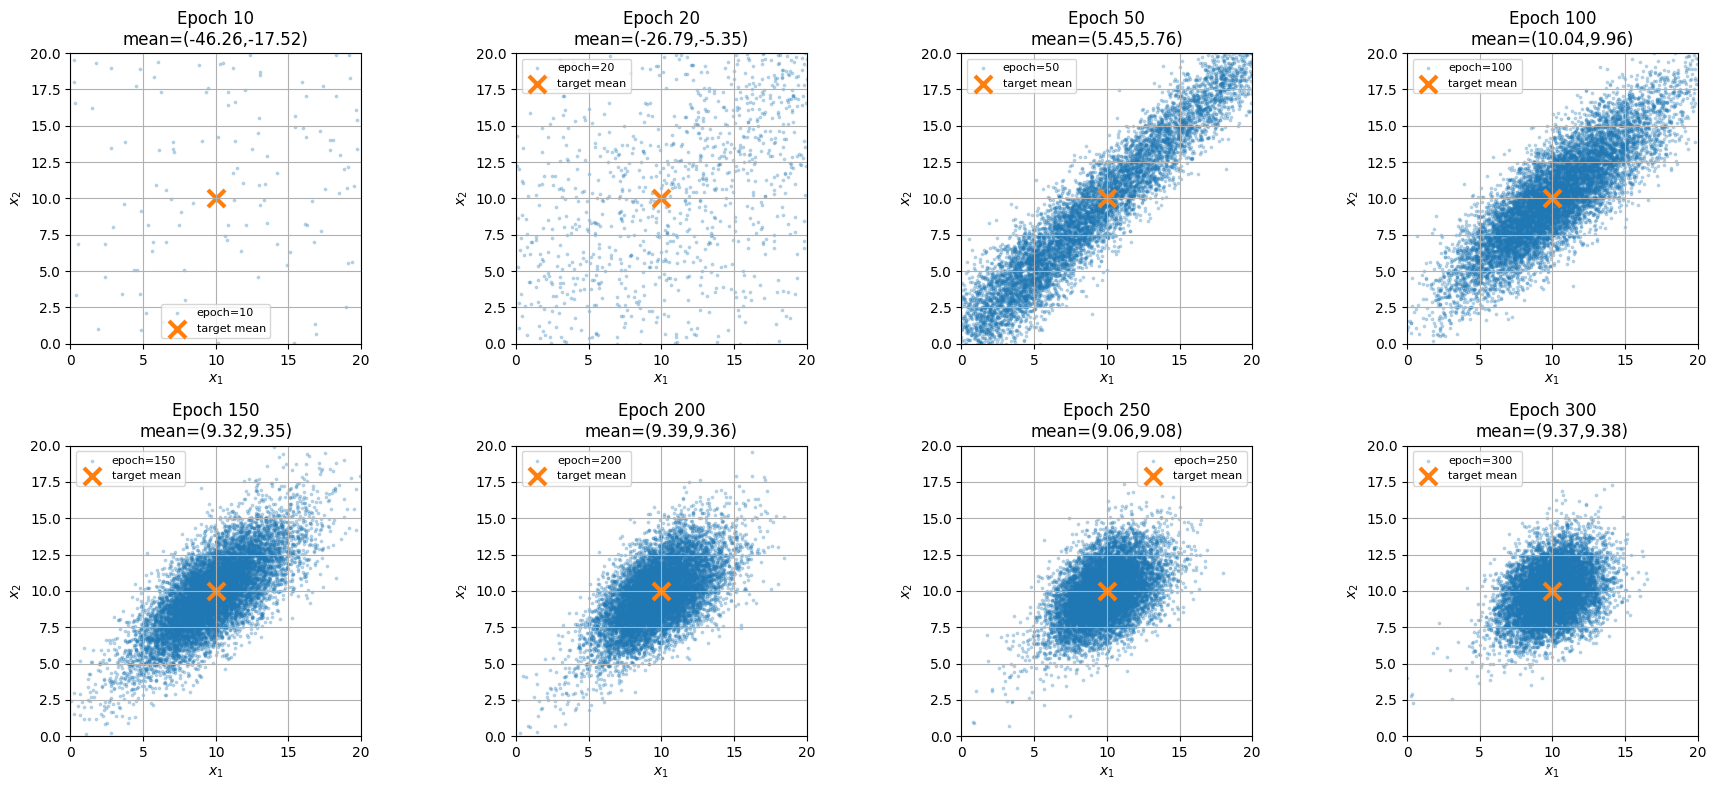

In [9]:
# ============================================================
# 2D Reverse sampling + indicators for each epoch
# ============================================================

sample_dict = {}
reverse_results = []
indicator_results = []

mu0_cpu = mu0.detach().cpu().numpy()
target_cov = var0 * np.eye(dim)

for epoch in epoch_list:

    model.load_state_dict(saved_models[epoch])
    model.eval()

    # indicators
    losses = compute_losses(model, x_eval_for_loss, t_eval_for_loss)

    indicator_results.append({
        "epoch": epoch,
        **losses
    })

    # start from p_T
    a_T, cond_var_T, mu_T, var_T = ou_params(T)

    x = (
        torch.randn(num_samples, dim, device=device)
        * np.sqrt(var_T)
        + mu_T
    )

    with torch.no_grad():

        for i in range(steps):

            t_now = T - i * dt
            t_now = max(t_now, 1e-5)

            t_tensor = torch.ones(num_samples, 1, device=device) * t_now

            score = model(x, t_tensor)
            noise = torch.randn_like(x)

            x = (
                x
                + (beta * x + sigma**2 * score) * dt
                + sigma * np.sqrt(dt) * noise
            )

    samples_reverse = x.detach().cpu().numpy()
    sample_dict[epoch] = samples_reverse

    reverse_mean = samples_reverse.mean(axis=0)
    reverse_cov = np.cov(samples_reverse.T)
    reverse_std = samples_reverse.std(axis=0)

    reverse_results.append({
        "epoch": epoch,

        "mean_x1": reverse_mean[0],
        "mean_x2": reverse_mean[1],

        "std_x1": reverse_std[0],
        "std_x2": reverse_std[1],

        "mean_error_norm": np.linalg.norm(reverse_mean - mu0_cpu),
        "std_error_norm": np.linalg.norm(reverse_std - np.sqrt(var0)),
        "cov_error": np.linalg.norm(reverse_cov - target_cov),
    })


df_reverse = pd.DataFrame(reverse_results)
df_indicators = pd.DataFrame(indicator_results)

df_summary = pd.merge(
    df_reverse,
    df_indicators,
    on="epoch",
    how="inner"
)

display(df_summary)


# ============================================================
# Plot 2D reverse samples side by side
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, epoch in zip(axes, epoch_list):

    samples = sample_dict[epoch]
    row = df_summary[df_summary["epoch"] == epoch].iloc[0]

    ax.scatter(
        samples[:, 0],
        samples[:, 1],
        s=3,
        alpha=0.25,
        label=f"epoch={epoch}"
    )

    ax.scatter(
        mu0_cpu[0],
        mu0_cpu[1],
        marker="x",
        s=150,
        linewidths=3,
        label="target mean"
    )

    ax.set_title(
        f"Epoch {epoch}\n"
        f"mean=({row['mean_x1']:.2f},{row['mean_x2']:.2f})"
    )

    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")

    ax.set_xlim(0, 20)
    ax.set_ylim(0, 20)
    ax.set_aspect("equal", adjustable="box")

    ax.grid(True)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

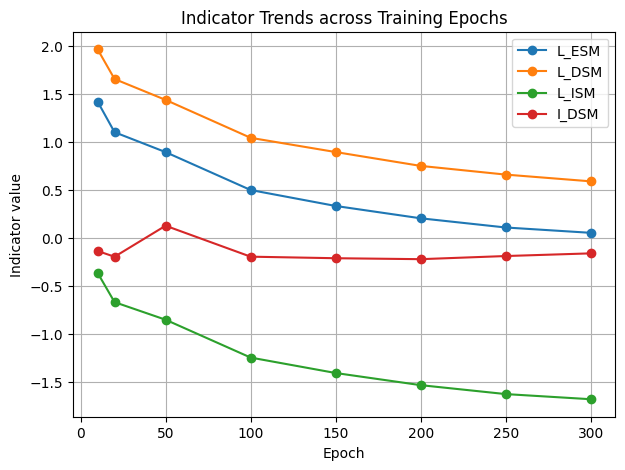

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.plot(df_summary["epoch"], df_summary["L_ESM"], marker="o", label="L_ESM")
plt.plot(df_summary["epoch"], df_summary["L_DSM"], marker="o", label="L_DSM")
plt.plot(df_summary["epoch"], df_summary["L_ISM"], marker="o", label="L_ISM")
plt.plot(df_summary["epoch"], df_summary["I_DSM"], marker="o", label="I_DSM")

plt.xlabel("Epoch")
plt.ylabel("Indicator value")
plt.title("Indicator Trends across Training Epochs")
plt.legend()
plt.grid(True)
plt.show()

#  想做漩渦的

In [12]:
import numpy as np
import torch

# ============================================================
# 2D OU Dataset with rotated Gaussian target
# x0 ~ N(mu0, Sigma0)
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dim = 2

mu0_np = np.array([10.0, 10.0], dtype=np.float32)

theta = np.pi / 4   # 45 degrees rotation

R_np = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
], dtype=np.float32)

D_np = np.diag([8.0, 0.5]).astype(np.float32)

Sigma0_np = R_np @ D_np @ R_np.T

beta = 1.0
sigma = np.sqrt(2.0)

T = 5.0
eps_t = 1e-3
N = 10000

# sample x0 ~ N(mu0, Sigma0)
x0_np = np.random.multivariate_normal(
    mean=mu0_np,
    cov=Sigma0_np,
    size=N
).astype(np.float32)

# random t
t_np = np.random.uniform(eps_t, T, N).astype(np.float32)
t_col = t_np.reshape(-1, 1)

a_t_np = np.exp(-beta * t_col).astype(np.float32)

cond_var_t_np = (
    sigma**2 / (2 * beta)
    * (1 - np.exp(-2 * beta * t_col))
).astype(np.float32)

cond_std_t_np = np.sqrt(cond_var_t_np).astype(np.float32)

eps_np = np.random.randn(N, dim).astype(np.float32)

xt_np = (
    a_t_np * x0_np
    + cond_std_t_np * eps_np
).astype(np.float32)

# marginal: Sigma_t = a_t^2 Sigma0 + cond_var_t I
mu_t_np = a_t_np * mu0_np

score_t_np = np.zeros_like(xt_np)

for i in range(N):

    Sigma_t_i = (
        (a_t_np[i, 0] ** 2) * Sigma0_np
        + cond_var_t_np[i, 0] * np.eye(dim)
    )

    Sigma_t_inv_i = np.linalg.inv(Sigma_t_i)

    score_t_np[i] = -Sigma_t_inv_i @ (xt_np[i] - mu_t_np[i])

# conditional score
cond_score_np = (
    -(xt_np - a_t_np * x0_np)
    / cond_var_t_np
).astype(np.float32)

# torch tensors
mu0 = torch.tensor(mu0_np, device=device)
Sigma0 = torch.tensor(Sigma0_np, device=device)

x0_train = torch.tensor(x0_np, device=device)
xt_train = torch.tensor(xt_np, device=device)
t_train = torch.tensor(t_np, device=device).view(-1, 1)

score_t_train = torch.tensor(score_t_np, device=device)
cond_score_train = torch.tensor(cond_score_np, device=device)

print("Sigma0:")
print(Sigma0_np)

print("x0 mean:", x0_np.mean(axis=0))
print("x0 cov:")
print(np.cov(x0_np.T))

print("xt mean:", xt_np.mean(axis=0))
print("xt cov:")
print(np.cov(xt_np.T))

Sigma0:
[[4.2499995 3.7499998]
 [3.7499998 4.2499995]]
x0 mean: [10.010936  9.998168]
x0 cov:
[[4.25856997 3.76089452]
 [3.76089452 4.27343223]]
xt mean: [2.018294  2.0206141]
xt cov:
[[7.59645455 6.6242172 ]
 [6.6242172  7.55752061]]


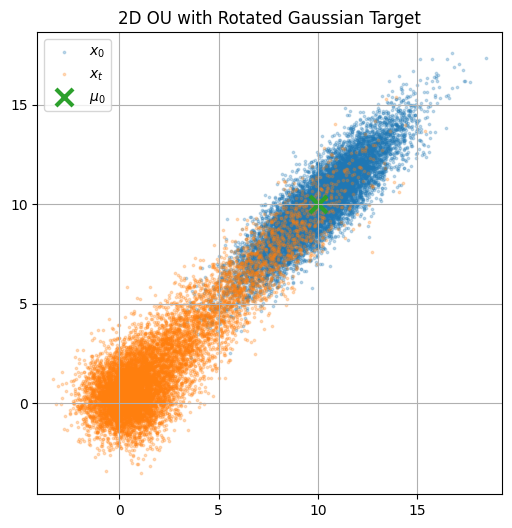

In [13]:
plt.figure(figsize=(6, 6))

plt.scatter(
    x0_np[:, 0],
    x0_np[:, 1],
    s=3,
    alpha=0.25,
    label=r"$x_0$"
)

plt.scatter(
    xt_np[:, 0],
    xt_np[:, 1],
    s=3,
    alpha=0.25,
    label=r"$x_t$"
)

plt.scatter(
    mu0_np[0],
    mu0_np[1],
    marker="x",
    s=150,
    linewidths=3,
    label=r"$\mu_0$"
)

plt.axis("equal")
plt.grid(True)
plt.legend()
plt.title("2D OU with Rotated Gaussian Target")

plt.show()

# 最底